# Seleccion de Caracteristicas Multimetodo (Optimizado)
Objetivo: seleccionar variables para `tipo_violencia` y `nivel_riesgo_victima` con una estrategia multimetodo, controlando el consumo de RAM y exportando resultados en CSV.

## 1) Librerias

In [1]:
# !pip install pandas pyarrow numpy scipy scikit-learn matplotlib seaborn
import gc
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 180)
sns.set(style="whitegrid")


## 2) Carga de datos

In [2]:
PARQUET_PATH = "/home/munasqa/MAESTRIA/opencode/base_modelado.parquet"
df = pd.read_parquet(PARQUET_PATH)

if "nivel_de_riesgo_victima" in df.columns and "nivel_riesgo_victima" not in df.columns:
    df = df.rename(columns={"nivel_de_riesgo_victima": "nivel_riesgo_victima"})

targets = ["tipo_violencia", "nivel_riesgo_victima"]
for t in targets:
    if t not in df.columns:
        raise ValueError(f"Falta target: {t}")

print("Shape base:", df.shape)
display(df[targets].head())


Shape base: (932860, 131)


,tipo_violencia,nivel_riesgo_victima
0,1,1
1,0,0
2,0,0
3,2,1
4,2,1


## 3) Preparacion de features (ahorro de RAM)
- Se excluyen targets y columnas de leakage obvio.
- Se tipifican categoricas y numericas.
- Se aplica downcast numerico (`float32`/`int32`) para reducir memoria.

In [3]:
leakage_obvio = [
    "tipo_violencia",
    "nivel_riesgo_victima",
    "tipo_violencia_lbl",
    "nivel_riesgo_victima_lbl",
    "tipo_violencia_orig",
    "nivel_riesgo_victima_orig",
]
features = [c for c in df.columns if c not in leakage_obvio]
X_raw = df[features].copy()

for c in X_raw.columns:
    if str(X_raw[c].dtype) in ["object", "category"]:
        X_raw[c] = X_raw[c].astype(str).fillna("desconocido")
    else:
        X_raw[c] = pd.to_numeric(X_raw[c], errors="coerce")
        med = X_raw[c].median()
        X_raw[c] = X_raw[c].fillna(med if pd.notna(med) else 0)
        X_raw[c] = pd.to_numeric(X_raw[c], downcast="float")

print("Features candidatas:", len(features))
print("Memoria aprox X_raw (MB):", round(X_raw.memory_usage(deep=True).sum() / 1024**2, 2))


Features candidatas: 127
Memoria aprox X_raw (MB): 6024.19


## 3.1) Chequeo rapido de leakage (antes de seleccionar variables)
Se busca detectar columnas sospechosas: copias del target, derivados directos (`*_orig`, `*_lbl`) o variables con acuerdo casi perfecto con el target.

In [4]:
def leakage_audit(X_df, y_series, target_name, sample_size=120000, random_state=42):
    y = pd.to_numeric(y_series, errors="coerce")
    mask = y.notna()
    y = y[mask].astype(int)
    X = X_df.loc[mask].copy()

    if len(y) > sample_size:
        _, X, _, y = train_test_split(X, y, test_size=sample_size, stratify=y, random_state=random_state)

    suspicious_name_tokens = ["_orig", "_lbl", "tipo_violencia", "nivel_riesgo"]
    by_name = [c for c in X.columns if any(tok in c for tok in suspicious_name_tokens)]

    rows = []
    y_str = y.astype(str)
    for c in X.columns:
        x = X[c]
        x_num = pd.to_numeric(x, errors="coerce")

        exact_num = False
        if x_num.notna().sum() > 0:
            valid = x_num.notna()
            exact_num = bool((x_num[valid].astype(int) == y[valid]).all()) if valid.sum() > 0 else False

        x_str = x.astype(str)
        agreement = float((x_str == y_str).mean())

        rows.append((c, exact_num, agreement))

    rep = pd.DataFrame(rows, columns=["feature", "exact_copy_numeric", "agreement_vs_target_str"])
    rep["name_suspicious"] = rep["feature"].isin(by_name).astype(int)
    rep["leakage_flag"] = ((rep["exact_copy_numeric"]) | (rep["agreement_vs_target_str"] >= 0.98) | (rep["name_suspicious"] == 1)).astype(int)

    rep = rep.sort_values(["leakage_flag", "agreement_vs_target_str"], ascending=[False, False]).reset_index(drop=True)
    return rep

# Ejecutar auditoria de leakage para ambos targets
leak_tipo = leakage_audit(X_raw, df["tipo_violencia"], "tipo_violencia")
leak_riesgo = leakage_audit(X_raw, df["nivel_riesgo_victima"], "nivel_riesgo_victima")

print("Posibles leakage - tipo_violencia")
display(leak_tipo.head(20))
print("Posibles leakage - nivel_riesgo_victima")
display(leak_riesgo.head(20))

# Si detectas columnas no validas para modelado, agrégalas a leakage_obvio en la celda 3.


Posibles leakage - tipo_violencia


,feature,exact_copy_numeric,agreement_vs_target_str,name_suspicious,leakage_flag
0,primera_vez_agrede,False,0.446492,0,0
1,victima_extranjera,False,0.446325,0,0
2,continua_recibiendo_tratamiento,False,0.446167,0,0
3,agresor_extranjero,False,0.444917,0,0
4,caso_tentativa_de_feminicidio,False,0.425850,0,0
5,informante,False,0.425642,0,0
6,trabaja_victima,False,0.425167,0,0
7,interpuso_denuncia,False,0.424358,0,0
8,sexo_victima,False,0.421283,0,0
9,estudia,False,0.406950,0,0


Posibles leakage - nivel_riesgo_victima


,feature,exact_copy_numeric,agreement_vs_target_str,name_suspicious,leakage_flag
0,desea_patrocinio_legal,False,0.515200,0,0
1,estado_victima_u_a,False,0.514025,0,0
2,victima_peruana,False,0.512600,0,0
3,victima_cuenta_dni,False,0.510125,0,0
4,agresor_peruano,False,0.508542,0,0
5,agresor_cuenta_dni,False,0.504792,0,0
6,redes_fam_soc,False,0.495275,0,0
7,ningun_tratamiento,False,0.490700,0,0
8,sexo_agresor,False,0.490358,0,0
9,vinculo_afectivo_familia,False,0.484008,0,0


## 4) Que hace cada algoritmo (explicado simple)

- **Cramer's V (filtro)**: mide asociacion entre una feature categorica y el target. Cerca de 0 = poca asociacion; cerca de 1 = alta asociacion.
- **Mutual Information (filtro)**: mide cuanta informacion aporta una variable sobre el target, capturando relaciones no lineales. Mayor MI = mayor utilidad potencial.
- **Random Forest Importance (embedded)**: el bosque asigna importancia segun cuanto ayuda una variable a reducir impureza al hacer splits.
- **Permutation Importance (embedded/model-agnostic)**: con el modelo ya entrenado, se desordena una variable y se mide cuanto cae el desempeño. Si cae mucho, la variable era importante.
- **RFECV (wrapper)**: elimina variables en pasos, reentrena y valida con CV para encontrar el subconjunto que mejor rendimiento logra.

Finalmente, se normalizan rankings y se crea un **score de consenso** ponderado para tener un ranking robusto.

## 5) Funciones auxiliares

In [5]:
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan, np.nan
    chi2, p, _, _ = chi2_contingency(tab)
    n = tab.values.sum()
    r, k = tab.shape
    den = min(r - 1, k - 1)
    v = np.sqrt((chi2 / n) / den) if den > 0 else np.nan
    return v, p


def cap_cardinality(series, top_n=80):
    s = series.astype(str)
    keep = s.value_counts(dropna=False).head(top_n).index
    return s.where(s.isin(keep), "otros")


def to_ordinal_encoded(X_df):
    X = X_df.copy()
    cat_cols = [c for c in X.columns if str(X[c].dtype) in ["object", "category"]]
    num_cols = [c for c in X.columns if c not in cat_cols]

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    if cat_cols:
        X[cat_cols] = enc.fit_transform(X[cat_cols]).astype(np.float32)

    for c in num_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce").fillna(pd.to_numeric(X[c], errors="coerce").median())
        X[c] = pd.to_numeric(X[c], downcast="float")

    return X


def rank_to_score(df_rank, score_col, feature_col="feature", descending=True):
    r = df_rank[[feature_col, score_col]].dropna().copy()
    if r.empty:
        return pd.DataFrame(columns=["feature", "score"])
    r = r.sort_values(score_col, ascending=not descending).reset_index(drop=True)
    r["score"] = np.linspace(1.0, 0.0, len(r), endpoint=False)
    return r[[feature_col, "score"]]


def run_feature_selection_for_target(df_all, X_all, target, sample_size=50000, random_state=42):
    y_full = pd.to_numeric(df_all[target], errors="coerce")
    mask = y_full.notna()
    y_full = y_full[mask].astype(int)
    X_full = X_all.loc[mask]

    if len(y_full) > sample_size:
        _, X_use, _, y = train_test_split(
            X_full,
            y_full,
            test_size=sample_size,
            stratify=y_full,
            random_state=random_state,
        )
    else:
        X_use = X_full.copy()
        y = y_full.copy()

    print(f"Target: {target} | muestra usada: {len(y)}")

    rows_cv = []
    y_cat = y.astype(str)
    for c in X_use.columns:
        vals = cap_cardinality(X_use[c], top_n=80)
        v, p = cramers_v(vals, y_cat)
        rows_cv.append((c, v, p))
    r_cv = pd.DataFrame(rows_cv, columns=["feature", "cramers_v", "p_value"]).dropna()

    X_enc = to_ordinal_encoded(X_use)
    mi_vals = mutual_info_classif(X_enc, y, discrete_features="auto", random_state=random_state)
    r_mi = pd.DataFrame({"feature": X_enc.columns, "mi": mi_vals})

    Xtr, Xte, ytr, yte = train_test_split(X_enc, y, test_size=0.2, stratify=y, random_state=random_state)

    rf = RandomForestClassifier(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=5,
        random_state=random_state,
        n_jobs=2,
        class_weight="balanced_subsample",
    )
    rf.fit(Xtr, ytr)
    r_rf = pd.DataFrame({"feature": X_enc.columns, "rf_importance": rf.feature_importances_})

    top_perm = r_rf.sort_values("rf_importance", ascending=False).head(min(40, len(r_rf)))["feature"].tolist()
    rf_perm = RandomForestClassifier(
        n_estimators=80,
        max_depth=16,
        min_samples_leaf=5,
        random_state=random_state,
        n_jobs=2,
        class_weight="balanced_subsample",
    )
    rf_perm.fit(Xtr[top_perm], ytr)
    perm = permutation_importance(
        rf_perm,
        Xte[top_perm],
        yte,
        n_repeats=3,
        random_state=random_state,
        n_jobs=2,
        scoring="f1_macro",
    )
    r_perm = pd.DataFrame({"feature": top_perm, "perm_importance": perm.importances_mean})

    top_for_rfe = r_mi.sort_values("mi", ascending=False).head(min(25, len(r_mi)))["feature"].tolist()
    X_rfe = X_enc[top_for_rfe].copy()
    rfe_est = RandomForestClassifier(
        n_estimators=80,
        max_depth=14,
        min_samples_leaf=6,
        random_state=random_state,
        n_jobs=2,
        class_weight="balanced_subsample",
    )
    rfecv = RFECV(
        estimator=rfe_est,
        step=5,
        cv=3,
        scoring="f1_macro",
        min_features_to_select=5,
        n_jobs=2,
    )
    rfecv.fit(X_rfe, y)
    r_rfe = pd.DataFrame({"feature": X_rfe.columns, "rfe_rank": rfecv.ranking_, "rfe_selected": rfecv.support_.astype(int)})

    s_cv = rank_to_score(r_cv, "cramers_v", descending=True)
    s_mi = rank_to_score(r_mi, "mi", descending=True)
    s_rf = rank_to_score(r_rf, "rf_importance", descending=True)
    s_perm = rank_to_score(r_perm, "perm_importance", descending=True)
    s_rfe = r_rfe[["feature", "rfe_selected"]].copy()
    s_rfe["score"] = s_rfe["rfe_selected"].astype(float)
    s_rfe = s_rfe[["feature", "score"]]

    pool = pd.DataFrame({"feature": X_enc.columns}).drop_duplicates()
    for name, s in [("cv", s_cv), ("mi", s_mi), ("rf", s_rf), ("perm", s_perm), ("rfe", s_rfe)]:
        pool = pool.merge(s.rename(columns={"score": f"score_{name}"}), on="feature", how="left")

    pool = pool.fillna(0)
    pool["score_consenso"] = (
        0.20 * pool["score_cv"]
        + 0.25 * pool["score_mi"]
        + 0.25 * pool["score_rf"]
        + 0.20 * pool["score_perm"]
        + 0.10 * pool["score_rfe"]
    )
    pool = pool.sort_values("score_consenso", ascending=False).reset_index(drop=True)

    yhat = rf.predict(Xte)
    f1m = f1_score(yte, yhat, average="macro")

    out = {
        "cv": r_cv.sort_values("cramers_v", ascending=False),
        "mi": r_mi.sort_values("mi", ascending=False),
        "rf": r_rf.sort_values("rf_importance", ascending=False),
        "perm": r_perm.sort_values("perm_importance", ascending=False),
        "rfe": r_rfe.sort_values(["rfe_selected", "rfe_rank"], ascending=[False, True]),
        "consenso": pool,
        "rf_f1_macro_test": f1m,
    }

    del X_full, X_use, X_enc, Xtr, Xte, ytr, yte, rf, rf_perm, X_rfe
    gc.collect()

    return out


def pareto_front(df_obj):
    keep = np.ones(len(df_obj), dtype=bool)
    vals = df_obj[["obj_error", "obj_nfeat"]].to_numpy()
    for i in range(len(vals)):
        if not keep[i]:
            continue
        dominated = (vals[:, 0] <= vals[i, 0]) & (vals[:, 1] <= vals[i, 1]) & ((vals[:, 0] < vals[i, 0]) | (vals[:, 1] < vals[i, 1]))
        dominated[i] = False
        if dominated.any():
            keep[i] = False
    return df_obj.loc[keep].copy()


def run_moes_rf_for_target(df_all, X_all, target, sample_size=50000, random_state=42, n_generations=10, pop_size=40, min_features=8):
    y_full = pd.to_numeric(df_all[target], errors="coerce")
    mask = y_full.notna()
    y_full = y_full[mask].astype(int)
    X_full = X_all.loc[mask]

    if len(y_full) > sample_size:
        _, X_use, _, y = train_test_split(X_full, y_full, test_size=sample_size, stratify=y_full, random_state=random_state)
    else:
        X_use = X_full.copy()
        y = y_full.copy()

    X_enc = to_ordinal_encoded(X_use)
    Xtr, Xte, ytr, yte = train_test_split(X_enc, y, test_size=0.2, stratify=y, random_state=random_state)

    seed_rf = RandomForestClassifier(n_estimators=80, max_depth=14, min_samples_leaf=6, random_state=random_state, n_jobs=2, class_weight="balanced_subsample")
    seed_rf.fit(Xtr, ytr)
    r_seed = pd.DataFrame({"feature": X_enc.columns, "imp": seed_rf.feature_importances_}).sort_values("imp", ascending=False)
    candidate_features = r_seed.head(min(40, len(r_seed)))["feature"].tolist()

    rng = np.random.default_rng(random_state)

    def evaluate_subset(mask_arr):
        if mask_arr.sum() < min_features:
            return 1.0, 999
        sel = [candidate_features[i] for i in range(len(candidate_features)) if mask_arr[i] == 1]
        model = RandomForestClassifier(n_estimators=70, max_depth=12, min_samples_leaf=6, random_state=random_state, n_jobs=2, class_weight="balanced_subsample")
        model.fit(Xtr[sel], ytr)
        pred = model.predict(Xte[sel])
        f1m = f1_score(yte, pred, average="macro")
        return 1.0 - f1m, len(sel)

    pop = rng.integers(0, 2, size=(pop_size, len(candidate_features)), dtype=np.int8)
    for i in range(pop_size):
        if pop[i].sum() < min_features:
            idx = rng.choice(len(candidate_features), size=min_features, replace=False)
            pop[i, idx] = 1

    history = []
    for gen in range(n_generations):
        rows = []
        for i in range(pop.shape[0]):
            err, nfeat = evaluate_subset(pop[i])
            rows.append((gen, i, err, nfeat, pop[i].copy()))
        df_gen = pd.DataFrame(rows, columns=["gen", "idx", "obj_error", "obj_nfeat", "mask"])
        history.append(df_gen)

        front = pareto_front(df_gen[["obj_error", "obj_nfeat", "mask"]])
        elite_masks = front["mask"].tolist()

        new_pop = []
        while len(new_pop) < pop_size:
            p1 = elite_masks[rng.integers(0, len(elite_masks))]
            p2 = elite_masks[rng.integers(0, len(elite_masks))]
            cut = rng.integers(1, len(candidate_features) - 1)
            child = np.concatenate([p1[:cut], p2[cut:]]).astype(np.int8)
            mut = rng.random(len(candidate_features)) < 0.06
            child[mut] = 1 - child[mut]
            if child.sum() < min_features:
                idx = rng.choice(len(candidate_features), size=min_features, replace=False)
                child[idx] = 1
            new_pop.append(child)
        pop = np.array(new_pop, dtype=np.int8)

    all_runs = pd.concat(history, ignore_index=True)
    front_all = pareto_front(all_runs[["obj_error", "obj_nfeat", "mask"]])
    best = front_all.sort_values(["obj_error", "obj_nfeat"], ascending=[True, True]).iloc[0]
    best_mask = best["mask"]
    best_features = [candidate_features[i] for i in range(len(candidate_features)) if best_mask[i] == 1]

    out = pd.DataFrame({"feature": best_features})
    out["moes_rank"] = np.arange(1, len(out) + 1)

    return {
        "moes_selected": out,
        "moes_pareto": front_all.sort_values(["obj_error", "obj_nfeat"], ascending=[True, True]).reset_index(drop=True),
        "moes_error_best": float(best["obj_error"]),
        "moes_f1_best": float(1.0 - best["obj_error"]),
        "moes_n_features_best": int(best["obj_nfeat"]),
    }


## 6) Seleccion para `tipo_violencia`
Esta celda calcula ranking multimetodo, imprime tabla Markdown Top 30 y grafica ranking final de consenso.

Target: tipo_violencia | muestra usada: 500000
## Top 30 consenso para tipo_violencia
| feature                         |   score_consenso |   score_cv |   score_mi |   score_rf |   score_perm |   score_rfe |
|:--------------------------------|-----------------:|-----------:|-----------:|-----------:|-------------:|------------:|
| violacion                       |         0.98622  |   1        |   0.968504 |   0.976378 |        1     |           1 |
| empujones                       |         0.985945 |   0.984252 |   0.976378 |   1        |        0.975 |           1 |
| gritos_insultos                 |         0.974488 |   0.992126 |   0.992126 |   0.992126 |        0.9   |           1 |
| punetazos                       |         0.971496 |   0.976378 |   0.96063  |   0.984252 |        0.95  |           1 |
| bofetadas                       |         0.927874 |   0.937008 |   0.944882 |   0.937008 |        0.85  |           1 |
| otra_vpsi                       |         0.923976 

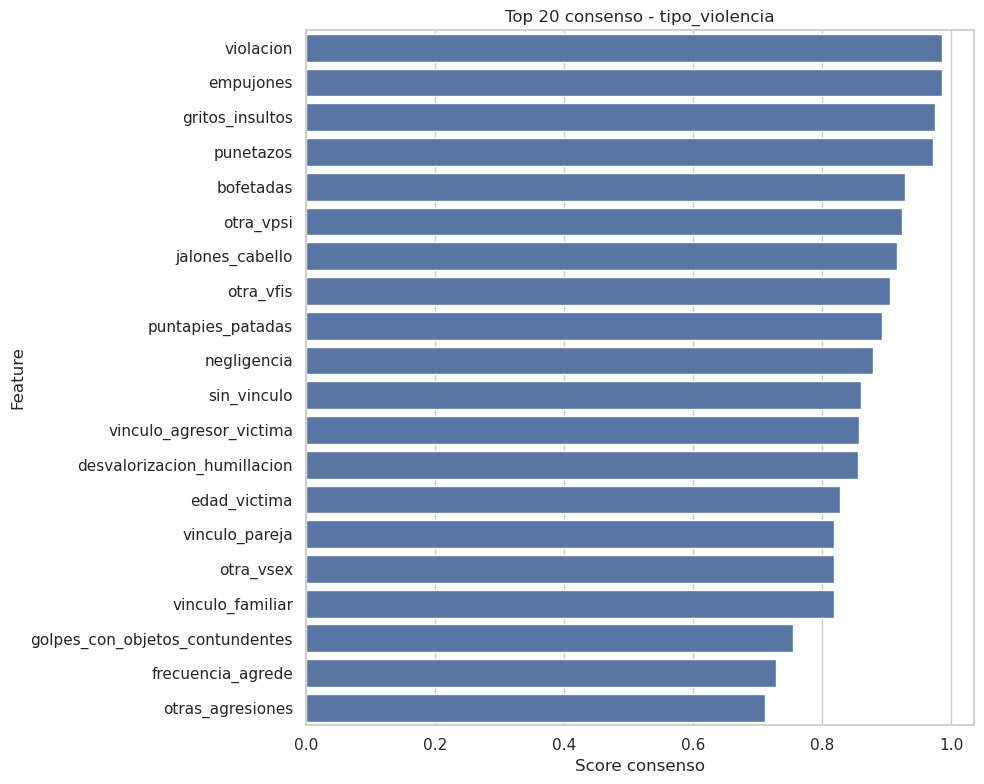

In [6]:
results = {}
SAMPLE_SIZE = 500000


results["tipo_violencia"] = run_feature_selection_for_target(
    df_all=df,
    X_all=X_raw,
    target="tipo_violencia",
    sample_size=SAMPLE_SIZE,
    random_state=52,
)

top30_tv = results["tipo_violencia"]["consenso"].head(30).copy()
print("## Top 30 consenso para tipo_violencia")
print(top30_tv[["feature", "score_consenso", "score_cv", "score_mi", "score_rf", "score_perm", "score_rfe"]].to_markdown(index=False))
print(f"\nF1 macro RF baseline (muestra): {results['tipo_violencia']['rf_f1_macro_test']:.4f}")

plt.figure(figsize=(10, 8))
sns.barplot(data=top30_tv.head(20), x="score_consenso", y="feature", orient="h")
plt.title("Top 20 consenso - tipo_violencia")
plt.xlabel("Score consenso")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 7) Seleccion para `nivel_riesgo_victima`
Mismo flujo: calculo multimetodo, tabla Markdown Top 30 y grafico de ranking final.

Target: nivel_riesgo_victima | muestra usada: 500000


/usr/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## Top 30 consenso para nivel_riesgo_victima
| feature                         |   score_consenso |   score_cv |   score_mi |   score_rf |   score_perm |   score_rfe |
|:--------------------------------|-----------------:|-----------:|-----------:|-----------:|-------------:|------------:|
| ubigeo_nombre                   |         0.993307 |   0.976378 |   0.992126 |   1        |        1     |           1 |
| cem                             |         0.981063 |   1        |   1        |   0.984252 |        0.925 |           1 |
| ubigeo_codigo                   |         0.963858 |   0.968504 |   0.984252 |   0.976378 |        0.9   |           1 |
| factor_agresor_consumo_alcohol  |         0.962835 |   0.992126 |   0.905512 |   0.992126 |        0.95  |           1 |
| amenaza_de_muerte               |         0.916732 |   0.984252 |   0.811024 |   0.968504 |        0.875 |           1 |
| factor_agresor_consume_droga    |         0.910472 |   0.96063  |   0.976378 |   0.937008 | 

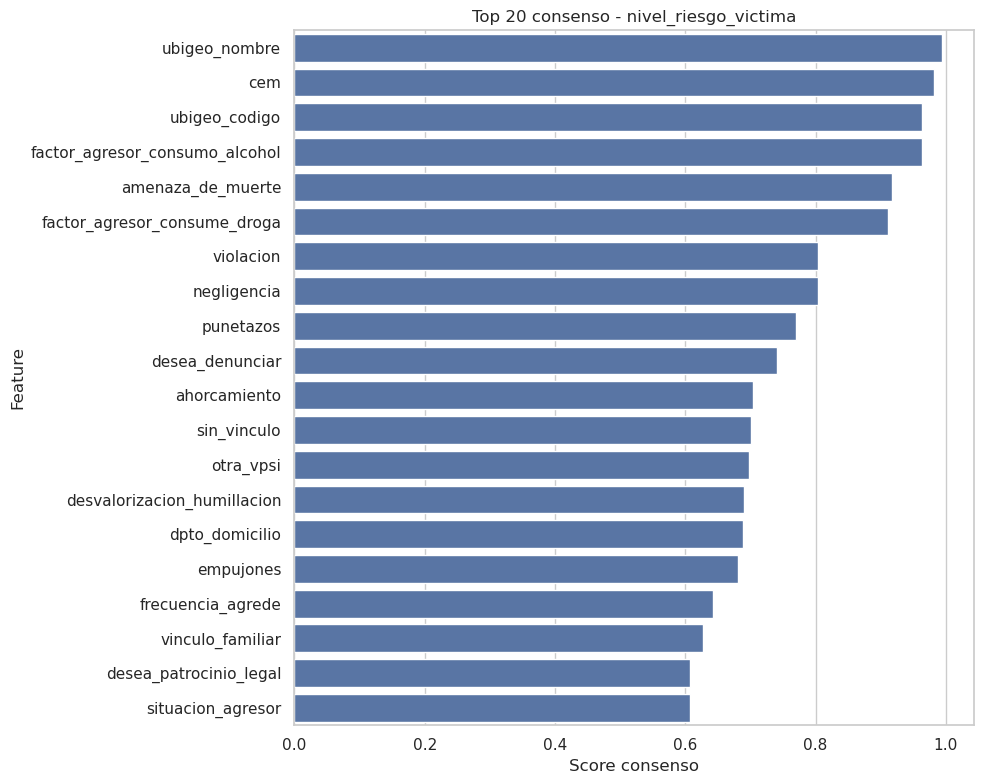

In [7]:
results["nivel_riesgo_victima"] = run_feature_selection_for_target(
    df_all=df,
    X_all=X_raw,
    target="nivel_riesgo_victima",
    sample_size=SAMPLE_SIZE,
    random_state=52,
)

top30_nr = results["nivel_riesgo_victima"]["consenso"].head(30).copy()
print("## Top 30 consenso para nivel_riesgo_victima")
print(top30_nr[["feature", "score_consenso", "score_cv", "score_mi", "score_rf", "score_perm", "score_rfe"]].to_markdown(index=False))
print(f"\nF1 macro RF baseline (muestra): {results['nivel_riesgo_victima']['rf_f1_macro_test']:.4f}")

plt.figure(figsize=(10, 8))
sns.barplot(data=top30_nr.head(20), x="score_consenso", y="feature", orient="h")
plt.title("Top 20 consenso - nivel_riesgo_victima")
plt.xlabel("Score consenso")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 8) Contexto MOES y aplicacion en esta tesis

**Que es MOES**
- MOES (*Multi-Objective Evolutionary Search*) es una estrategia evolutiva de seleccion de variables.
- En lugar de optimizar una sola metrica, optimiza simultaneamente dos objetivos: minimizar error predictivo y minimizar numero de variables.
- El resultado natural de MOES es un frente de Pareto: conjunto de soluciones no dominadas (no existe otra mejor en ambos objetivos al mismo tiempo).

**Por que lo aplicamos a nuestra data**
- Nuestra seleccion hibrida (Cramer's V + MI + RF + Permutation + RFECV) produce un ranking robusto, pero no optimiza explicitamente el tamano minimo del subconjunto.
- MOES nos permite contrastar: "que tan cerca del mejor desempeno podemos estar usando menos variables".
- Esta comparacion fortalece la metodologia de tesis al evaluar dos paradigmas: ranking por consenso vs busqueda evolutiva multiobjetivo.

**Nota tecnica**
- En este notebook implementamos una aproximacion practica de MOES-RF en sklearn para comparacion reproducible y costo computacional controlado.

## 9) MOES-RF para comparar con seleccion hibrida
Se ejecuta una busqueda evolutiva multiobjetivo (error y numero de variables) sobre un conjunto candidato de features y se compara contra el Top 30 de consenso.
En esta version se fuerza un minimo de variables (`min_features`) para evitar soluciones demasiado pequenas e inestables.

In [8]:
moes_results = {}
for t in targets:
    print(f"\n=== MOES-RF para {t} ===")
    moes_results[t] = run_moes_rf_for_target(
        df_all=df,
        X_all=X_raw,
        target=t,
        sample_size=SAMPLE_SIZE,
        random_state=42,
        n_generations=10,
        pop_size=40,
        min_features=8,
    )

    hybrid_top30 = set(results[t]["consenso"].head(30)["feature"].tolist())
    moes_set = set(moes_results[t]["moes_selected"]["feature"].tolist())
    inter = len(hybrid_top30.intersection(moes_set))
    union = len(hybrid_top30.union(moes_set)) if len(hybrid_top30.union(moes_set)) > 0 else 1
    jaccard = inter / union

    print(f"MOES F1 best: {moes_results[t]['moes_f1_best']:.4f}")
    print(f"MOES n_features best: {moes_results[t]['moes_n_features_best']}")
    print(f"Interseccion MOES vs Hybrid Top30: {inter}")
    print(f"Jaccard MOES vs Hybrid Top30: {jaccard:.4f}")

    display(moes_results[t]["moes_selected"].head(30))



=== MOES-RF para tipo_violencia ===
MOES F1 best: 0.9586
MOES n_features best: 22
Interseccion MOES vs Hybrid Top30: 21
Jaccard MOES vs Hybrid Top30: 0.6774


,feature,moes_rank
0,gritos_insultos,1
1,empujones,2
2,punetazos,3
3,violacion,4
4,vinculo_agresor_victima,5
5,otra_vpsi,6
6,otra_vfis,7
7,bofetadas,8
8,jalones_cabello,9
9,negligencia,10



=== MOES-RF para nivel_riesgo_victima ===
MOES F1 best: 0.5252
MOES n_features best: 16
Interseccion MOES vs Hybrid Top30: 12
Jaccard MOES vs Hybrid Top30: 0.3529


,feature,moes_rank
0,amenaza_de_muerte,1
1,violacion,2
2,ubigeo_nombre,3
3,ubigeo_codigo,4
4,factor_agresor_consume_droga,5
5,cem,6
6,otra_vpsi,7
7,vinculo_familiar,8
8,gritos_insultos,9
9,vinculo_agresor_victima,10


## 10) Exportables CSV
Se guardan rankings hibridos y resultados MOES para comparacion final.

In [9]:
OUT = "/home/munasqa/MAESTRIA/opencode"
for t in targets:
    results[t]["cv"].to_csv(f"{OUT}/ranking_cv_{t}.csv", index=False)
    results[t]["mi"].to_csv(f"{OUT}/ranking_mi_{t}.csv", index=False)
    results[t]["rf"].to_csv(f"{OUT}/ranking_rfimp_{t}.csv", index=False)
    results[t]["perm"].to_csv(f"{OUT}/ranking_perm_{t}.csv", index=False)
    results[t]["rfe"].to_csv(f"{OUT}/ranking_rfe_{t}.csv", index=False)
    results[t]["consenso"].head(30).to_csv(f"{OUT}/top30_consenso_{t}.csv", index=False)
    if 'moes_results' in globals() and t in moes_results:
        moes_results[t]["moes_selected"].to_csv(f"{OUT}/ranking_moes_{t}.csv", index=False)
        moes_results[t]["moes_pareto"].drop(columns=["mask"], errors="ignore").to_csv(f"{OUT}/pareto_moes_{t}.csv", index=False)

print("Exportables generados en:", OUT)


Exportables generados en: /home/munasqa/MAESTRIA/opencode


## 11) Glosario rapido para la etapa de modelado

- **Baseline**: modelo de referencia inicial; sirve para medir si las mejoras posteriores realmente aportan.
- **Jaccard**: similitud entre dos conjuntos de features. Formula: `|A ∩ B| / |A ∪ B|`.
- **F1-macro**: promedio del F1 por clase con igual peso (util cuando hay desbalance de clases).
- **MLP**: en este notebook se usa una red neuronal *Multilayer Perceptron*.
- **SMOTE / SMOTETomek**: tecnicas de remuestreo para tratar desbalance. Se aplican solo si mejoran metricas de forma consistente.

## 12) Plantilla de entrenamiento final (despues de decidir variables)
Esta seccion deja un flujo claro para comparar RF, XGB, CatBoost, RL y MLP sobre el subset final de variables por target.

In [6]:
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# Opcionales (instalar si faltan): xgboost, catboost, imbalanced-learn
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek
except Exception:
    SMOTE = None
    SMOTETomek = None


In [7]:
def _to_ordinal_encoded_local(X_df):
    X = X_df.copy()
    cat_cols = [c for c in X.columns if str(X[c].dtype) in ["object", "category"]]
    num_cols = [c for c in X.columns if c not in cat_cols]

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    if cat_cols:
        X[cat_cols] = enc.fit_transform(X[cat_cols]).astype(np.float32)

    for c in num_cols:
        xnum = pd.to_numeric(X[c], errors="coerce")
        med = xnum.median()
        X[c] = xnum.fillna(med if pd.notna(med) else 0)
        X[c] = pd.to_numeric(X[c], downcast="float")
    return X


def evaluate_models_for_target(df_all, X_all, target, feature_list, random_state=42, use_smote=False, use_smotetomek=False):
    y = pd.to_numeric(df_all[target], errors="coerce")
    mask = y.notna()
    y = y[mask].astype(int)
    X = X_all.loc[mask, feature_list].copy()
    X = _to_ordinal_encoded_local(X)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)

    if use_smotetomek and SMOTETomek is not None:
        sampler = SMOTETomek(random_state=random_state)
        Xtr, ytr = sampler.fit_resample(Xtr, ytr)
    elif use_smote and SMOTE is not None:
        sampler = SMOTE(random_state=random_state)
        Xtr, ytr = sampler.fit_resample(Xtr, ytr)

    models = {
        "RF": RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=2, class_weight="balanced_subsample"),
        "RL": LogisticRegression(max_iter=2000, random_state=random_state),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=random_state),
    }

    if XGBClassifier is not None:
        models["XGB"] = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=random_state, eval_metric="mlogloss")

    if CatBoostClassifier is not None:
        models["CatBoost"] = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, random_state=random_state, verbose=False)

    rows = []
    reports = {}
    for name, model in models.items():
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        f1m = f1_score(yte, pred, average="macro")
        rows.append({"target": target, "model": name, "f1_macro": float(f1m), "n_features": len(feature_list)})
        reports[name] = classification_report(yte, pred, output_dict=True)

    res = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
    return res, reports


## 13.1) Criterio de decision del numero final de variables (K)

La eleccion de K por target se define por un criterio de compromiso entre:
1. Desempeno predictivo (F1-macro), y
2. Parsimonia (menor numero de variables).

Para ello se combinan dos evidencias:
- **MOES-Pareto**: selecciona soluciones no dominadas en error vs numero de variables.
- **Consenso hibrido**: verifica estabilidad del ranking por multiples metodos (Cramer's V, MI, RF, Permutation, RFECV).

Decision aplicada en esta tesis:
- **`tipo_violencia`: K=22**
  - Mejor punto MOES con alto desempeno (`F1 ~= 0.9586`) y `22` variables.
  - Convergencia alta con el hibrido (interseccion 21/30; Jaccard 0.6774).
- **`nivel_riesgo_victima`: K=16**
  - Mejor punto MOES con `16` variables (`F1 ~= 0.5252`).
  - Menor convergencia entre metodos (interseccion 12/30; Jaccard 0.3529), por lo que no se recomienda reducir agresivamente por debajo de ese valor.

Este criterio deja trazabilidad clara de por que no se usa un K fijo para ambos targets.

## 13) Preparacion para entrenamiento final por target
Esta parte esta separada por target para evitar cierres por carga excesiva. Ejecuta una celda por vez.

K tipo_violencia = 22
K nivel_riesgo_victima = 16

Variables finales tipo_violencia:
['violacion', 'empujones', 'gritos_insultos', 'punetazos', 'bofetadas', 'otra_vpsi', 'jalones_cabello', 'otra_vfis', 'puntapies_patadas', 'negligencia', 'sin_vinculo', 'vinculo_agresor_victima', 'desvalorizacion_humillacion', 'edad_victima', 'vinculo_pareja', 'otra_vsex', 'vinculo_familiar', 'golpes_con_objetos_contundentes', 'frecuencia_agrede', 'otras_agresiones', 'ahorcamiento', 'latigazo']

Variables finales nivel_riesgo_victima:
['ubigeo_nombre', 'cem', 'ubigeo_codigo', 'factor_agresor_consumo_alcohol', 'amenaza_de_muerte', 'factor_agresor_consume_droga', 'violacion', 'negligencia', 'punetazos', 'desea_denunciar', 'ahorcamiento', 'sin_vinculo', 'otra_vpsi', 'desvalorizacion_humillacion', 'dpto_domicilio', 'empujones']


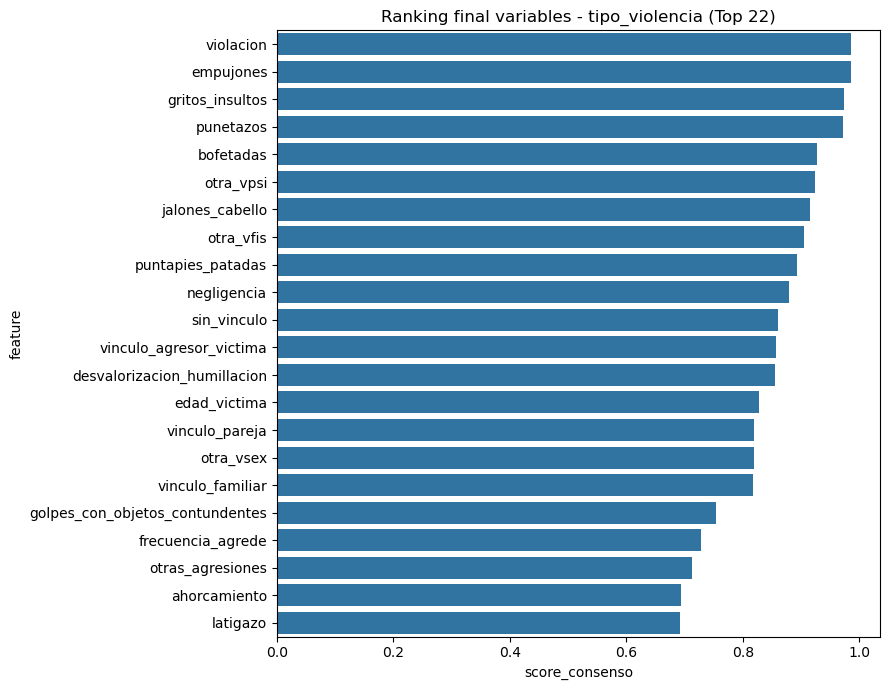

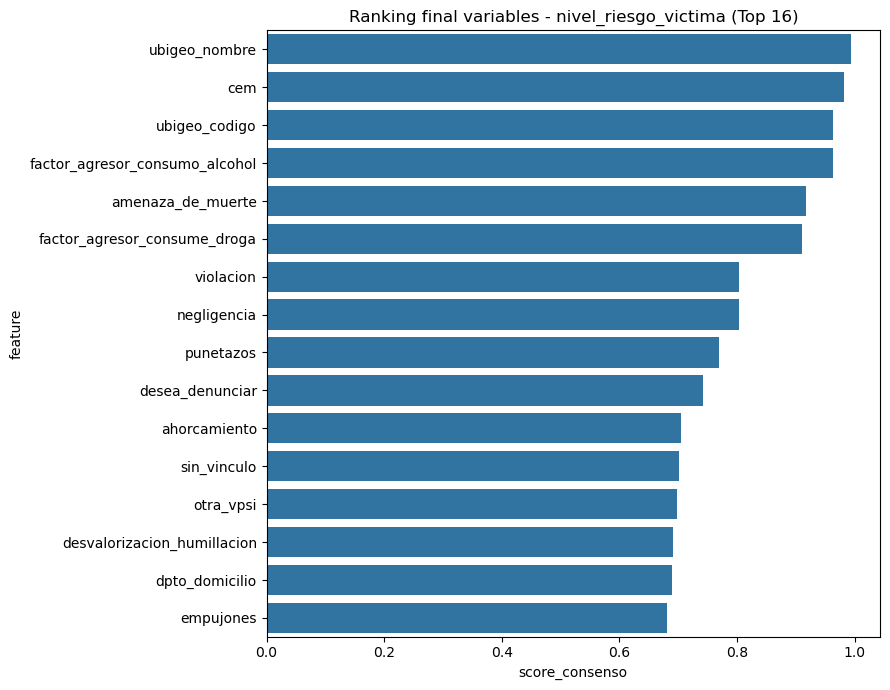

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

OUT = "/home/munasqa/MAESTRIA/opencode"
PARQUET_PATH = f"{OUT}/base_modelado.parquet"

df = pd.read_parquet(PARQUET_PATH)
if "nivel_de_riesgo_victima" in df.columns and "nivel_riesgo_victima" not in df.columns:
    df = df.rename(columns={"nivel_de_riesgo_victima": "nivel_riesgo_victima"})

leakage_obvio = [
    "tipo_violencia", "nivel_riesgo_victima",
    "tipo_violencia_lbl", "nivel_riesgo_victima_lbl",
    "tipo_violencia_orig", "nivel_riesgo_victima_orig",
]
features = [c for c in df.columns if c not in leakage_obvio]
X_raw = df[features].copy()

for c in X_raw.columns:
    if str(X_raw[c].dtype) in ["object", "category"]:
        X_raw[c] = X_raw[c].astype(str).fillna("desconocido")
    else:
        X_raw[c] = pd.to_numeric(X_raw[c], errors="coerce")
        med = X_raw[c].median()
        X_raw[c] = X_raw[c].fillna(med if pd.notna(med) else 0)
        X_raw[c] = pd.to_numeric(X_raw[c], downcast="float")

top_tipo = pd.read_csv(f"{OUT}/top30_consenso_tipo_violencia.csv")
top_riesgo = pd.read_csv(f"{OUT}/top30_consenso_nivel_riesgo_victima.csv")

K_TIPO = 22
K_RIESGO = 16

final_features = {
    "tipo_violencia": top_tipo.head(K_TIPO)["feature"].tolist(),
    "nivel_riesgo_victima": top_riesgo.head(K_RIESGO)["feature"].tolist(),
}

print(f"K tipo_violencia = {K_TIPO}")
print(f"K nivel_riesgo_victima = {K_RIESGO}")
print("\nVariables finales tipo_violencia:")
print(final_features["tipo_violencia"])
print("\nVariables finales nivel_riesgo_victima:")
print(final_features["nivel_riesgo_victima"])

plt.figure(figsize=(9, 7))
sns.barplot(data=top_tipo.head(K_TIPO), x="score_consenso", y="feature")
plt.title(f"Ranking final variables - tipo_violencia (Top {K_TIPO})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.barplot(data=top_riesgo.head(K_RIESGO), x="score_consenso", y="feature")
plt.title(f"Ranking final variables - nivel_riesgo_victima (Top {K_RIESGO})")
plt.tight_layout()
plt.show()


## 14) Funciones de entrenamiento y diagnostico
Entrena 5 modelos cuando estan disponibles (RF, RL, MLP, XGB, CatBoost), guarda resultados incrementales y permite exportar matriz de confusion y ROC del mejor modelo.

In [12]:
def plot_best_model_diagnostics(best_model, best_name, Xte, yte, target, out_dir):
    pred = best_model.predict(Xte)

    cm = confusion_matrix(yte, pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Matriz de confusion - {target} - Mejor: {best_name}")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/cm_best_{target}.png", dpi=160)
    plt.show()

    classes = np.sort(np.unique(yte))
    y_bin = label_binarize(yte, classes=classes)

    y_score = None
    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(Xte)
    elif hasattr(best_model, "decision_function"):
        y_score = best_model.decision_function(Xte)

    if y_score is None:
        print("ROC no disponible para este modelo")
        return

    if y_score.ndim == 1:
        y_score = np.vstack([1 - y_score, y_score]).T

    if y_score.shape[1] != len(classes):
        print("ROC omitido: dimensiones incompatibles")
        return

    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Clase {cls} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC multiclase OvR - {target} - Mejor: {best_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{out_dir}/roc_best_{target}.png", dpi=160)
    plt.show()


def _encode_for_training(X_df):
    from sklearn.preprocessing import OrdinalEncoder
    X = X_df.copy()
    cat_cols = [c for c in X.columns if str(X[c].dtype) in ["object", "category"]]
    num_cols = [c for c in X.columns if c not in cat_cols]
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    if cat_cols:
        X[cat_cols] = enc.fit_transform(X[cat_cols]).astype(np.float32)
    for c in num_cols:
        xnum = pd.to_numeric(X[c], errors="coerce")
        med = xnum.median()
        X[c] = xnum.fillna(med if pd.notna(med) else 0)
        X[c] = pd.to_numeric(X[c], downcast="float")
    return X


def run_training_for_target(target, feature_list, random_state=42, sample_train=120000, run_smote=False, run_smotetomek=False):
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import f1_score
    from sklearn.linear_model import LogisticRegression
    from sklearn.neural_network import MLPClassifier
    from sklearn.ensemble import RandomForestClassifier

    try:
        from xgboost import XGBClassifier as _XGBClassifier
    except Exception:
        _XGBClassifier = None

    try:
        from catboost import CatBoostClassifier as _CatBoostClassifier
    except Exception:
        _CatBoostClassifier = None
    y = pd.to_numeric(df[target], errors="coerce")
    mask = y.notna()
    y = y[mask].astype(int)
    X = X_raw.loc[mask, feature_list].copy()
    X = _encode_for_training(X)

    if len(y) > sample_train:
        _, X, _, y = train_test_split(X, y, test_size=sample_train, stratify=y, random_state=random_state)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)

    scenarios = [("baseline", False, False)]
    if run_smote and SMOTE is not None:
        scenarios.append(("smote", True, False))
    if run_smotetomek and SMOTETomek is not None:
        scenarios.append(("smotetomek", False, True))

    rows = []
    for scenario, use_smote, use_smotetomek in scenarios:
        Xtr_use, ytr_use = Xtr.copy(), ytr.copy()

        if use_smotetomek:
            sampler = SMOTETomek(random_state=random_state)
            Xtr_use, ytr_use = sampler.fit_resample(Xtr_use, ytr_use)
        elif use_smote:
            sampler = SMOTE(random_state=random_state)
            Xtr_use, ytr_use = sampler.fit_resample(Xtr_use, ytr_use)

        models = {
            "RF": RandomForestClassifier(n_estimators=120, random_state=random_state, n_jobs=2, class_weight="balanced_subsample"),
            "RL": LogisticRegression(max_iter=1500, random_state=random_state),
            "MLP": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=150, random_state=random_state),
        }

        if _XGBClassifier is not None:
            models["XGB"] = _XGBClassifier(n_estimators=120, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=random_state, eval_metric="mlogloss")

        if _CatBoostClassifier is not None:
            models["CatBoost"] = _CatBoostClassifier(iterations=120, depth=6, learning_rate=0.05, random_state=random_state, verbose=False)

        best_f1 = -1
        best_model = None
        best_name = None

        for name, model in models.items():
            model.fit(Xtr_use, ytr_use)
            pred = model.predict(Xte)
            f1m = f1_score(yte, pred, average="macro")
            rows.append({"target": target, "scenario": scenario, "model": name, "f1_macro": float(f1m), "n_features": len(feature_list), "n_train": len(Xtr_use), "n_test": len(Xte)})

            pd.DataFrame(rows).to_csv(f"{OUT}/resumen_modelos_{target}_parcial.csv", index=False)

            if f1m > best_f1:
                best_f1 = f1m
                best_model = model
                best_name = name

        print(f"Escenario {scenario} | Mejor modelo: {best_name} | F1_macro={best_f1:.4f}")
        plot_best_model_diagnostics(best_model, best_name, Xte, yte, f"{target}_{scenario}", OUT)

    out_df = pd.DataFrame(rows).sort_values(["scenario", "f1_macro"], ascending=[True, False]).reset_index(drop=True)
    out_df.to_csv(f"{OUT}/resumen_modelos_{target}.csv", index=False)
    return out_df


/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Escenario baseline | Mejor modelo: RL | F1_macro=0.9700


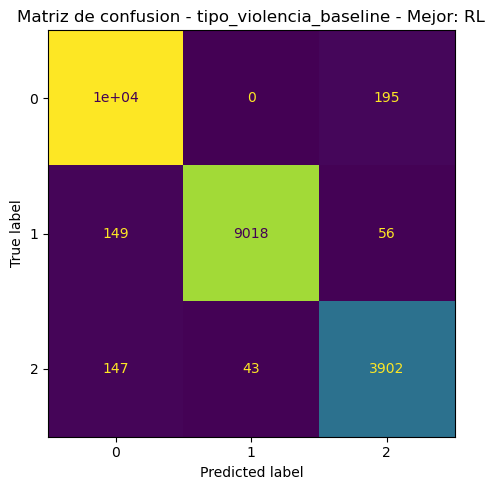

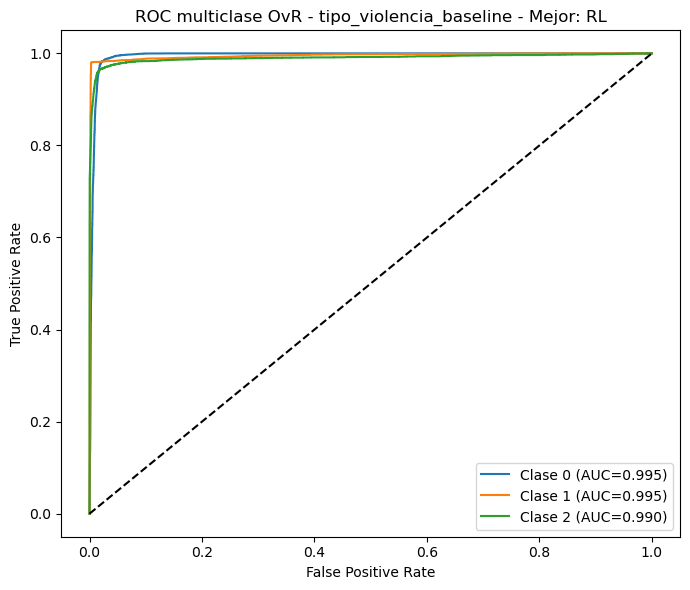

,target,scenario,model,f1_macro,n_features,n_train,n_test
0,tipo_violencia,baseline,RL,0.970027,22,96000,24000
1,tipo_violencia,baseline,MCP,0.969389,22,96000,24000
2,tipo_violencia,baseline,RF,0.968706,22,96000,24000


Generado: /home/munasqa/MAESTRIA/opencode/resumen_modelos_tipo_violencia.csv


In [10]:
# ENTRENAMIENTO SOLO tipo_violencia
# Tip: deja run_smote=False y run_smotetomek=False en primer intento para evitar cierres
resumen_modelos_tipo = run_training_for_target(
    target="tipo_violencia",
    feature_list=final_features["tipo_violencia"],
    random_state=42,
    sample_train=120000,
    run_smote=False,
    run_smotetomek=False,
)
display(resumen_modelos_tipo)
print("Generado:", f"{OUT}/resumen_modelos_tipo_violencia.csv")


/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Escenario baseline | Mejor modelo: RF | F1_macro=0.5304


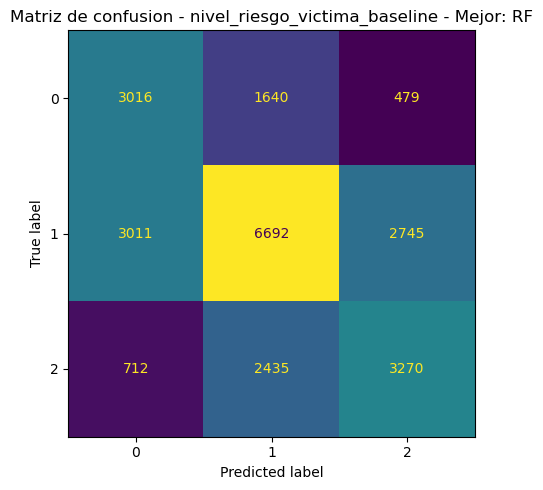

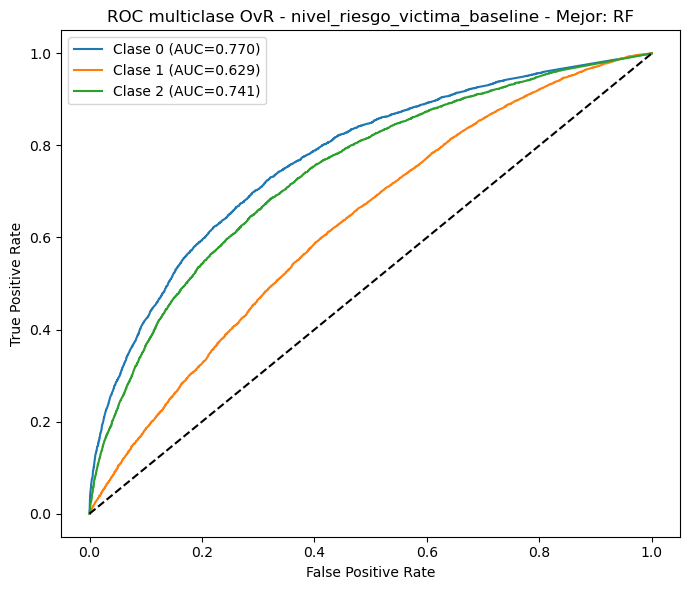

,target,scenario,model,f1_macro,n_features,n_train,n_test
0,nivel_riesgo_victima,baseline,RF,0.530356,16,96000,24000
1,nivel_riesgo_victima,baseline,MCP,0.469183,16,96000,24000
2,nivel_riesgo_victima,baseline,RL,0.362573,16,96000,24000


Generado: /home/munasqa/MAESTRIA/opencode/resumen_modelos_nivel_riesgo_victima.csv


In [11]:
# ENTRENAMIENTO SOLO nivel_riesgo_victima
# Tip: deja run_smote=False y run_smotetomek=False en primer intento para evitar cierres
resumen_modelos_riesgo = run_training_for_target(
    target="nivel_riesgo_victima",
    feature_list=final_features["nivel_riesgo_victima"],
    random_state=42,
    sample_train=120000,
    run_smote=False,
    run_smotetomek=False,
)
display(resumen_modelos_riesgo)
print("Generado:", f"{OUT}/resumen_modelos_nivel_riesgo_victima.csv")


In [12]:
# Consolidado final
resumen_modelos = pd.concat([resumen_modelos_tipo, resumen_modelos_riesgo], ignore_index=True)
display(resumen_modelos.sort_values(["target", "f1_macro"], ascending=[True, False]))
resumen_modelos.to_csv(f"{OUT}/resumen_modelos_final.csv", index=False)
print("Generado:", f"{OUT}/resumen_modelos_final.csv")


,target,scenario,model,f1_macro,n_features,n_train,n_test
3,nivel_riesgo_victima,baseline,RF,0.530356,16,96000,24000
4,nivel_riesgo_victima,baseline,MCP,0.469183,16,96000,24000
5,nivel_riesgo_victima,baseline,RL,0.362573,16,96000,24000
0,tipo_violencia,baseline,RL,0.970027,22,96000,24000
1,tipo_violencia,baseline,MCP,0.969389,22,96000,24000
2,tipo_violencia,baseline,RF,0.968706,22,96000,24000


Generado: /home/munasqa/MAESTRIA/opencode/resumen_modelos_final.csv


## 15) Benchmark directo: MOES vs Hibrido (mismo protocolo)
Aqui se compara de forma justa el subset de MOES contra el subset hibrido con los mismos modelos, mismo split y mismas metricas.

In [13]:
def run_moes_vs_hibrido(target, k, random_state=42, sample_train=120000, run_smote=False, run_smotetomek=False):
    hibrido_features = pd.read_csv(f"{OUT}/top30_consenso_{target}.csv").head(k)["feature"].tolist()
    moes_features = pd.read_csv(f"{OUT}/ranking_moes_{target}.csv")["feature"].head(k).tolist()

    res_h = run_training_for_target(target, hibrido_features, random_state=random_state, sample_train=sample_train, run_smote=run_smote, run_smotetomek=run_smotetomek).copy()
    res_h["subset_source"] = "hibrido"

    res_m = run_training_for_target(target, moes_features, random_state=random_state, sample_train=sample_train, run_smote=run_smote, run_smotetomek=run_smotetomek).copy()
    res_m["subset_source"] = "moes"

    out = pd.concat([res_h, res_m], ignore_index=True)
    out["k"] = k
    return out


/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Escenario baseline | Mejor modelo: RL | F1_macro=0.9700


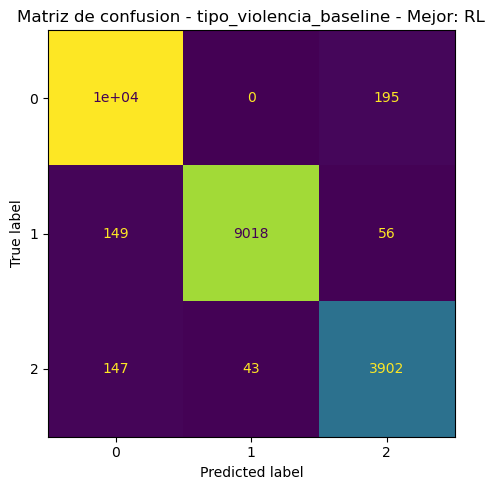

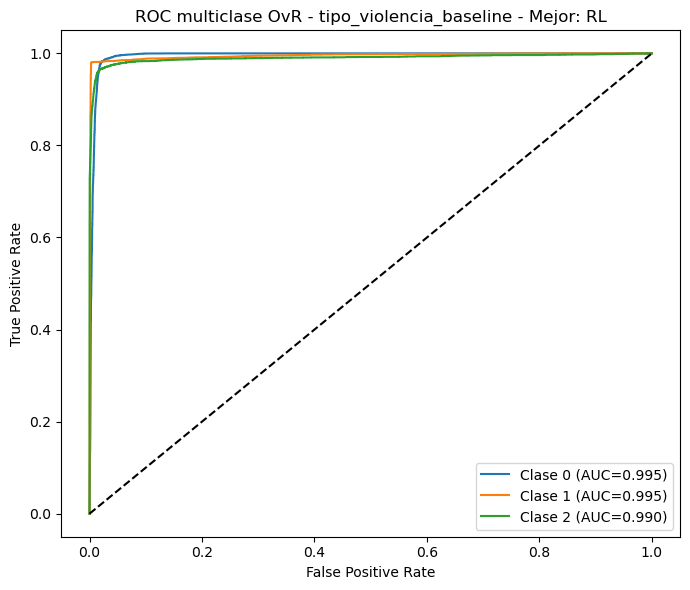

/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Escenario baseline | Mejor modelo: MLP | F1_macro=0.9630


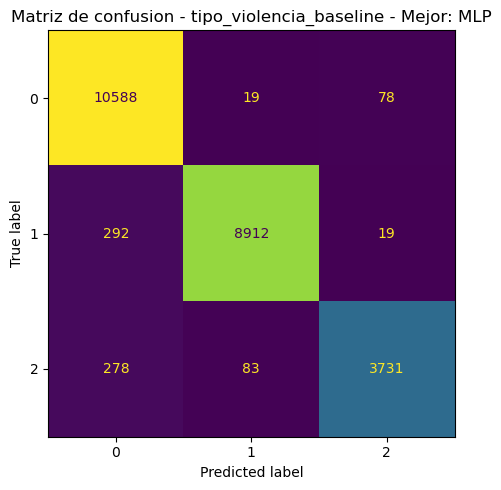

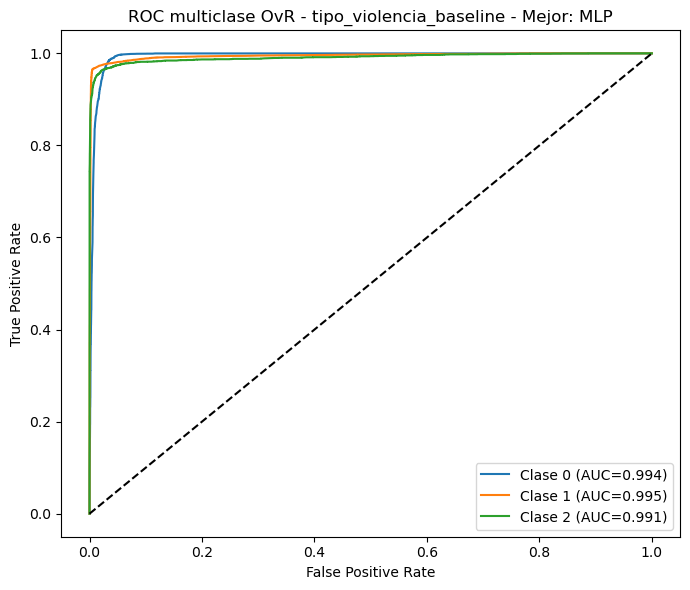

,target,scenario,model,f1_macro,n_features,n_train,n_test,subset_source,k
0,tipo_violencia,baseline,RL,0.970027,22,96000,24000,hibrido,22
1,tipo_violencia,baseline,MLP,0.969389,22,96000,24000,hibrido,22
2,tipo_violencia,baseline,RF,0.968706,22,96000,24000,hibrido,22
3,tipo_violencia,baseline,MLP,0.962996,22,96000,24000,moes,22
4,tipo_violencia,baseline,RL,0.962090,22,96000,24000,moes,22
5,tipo_violencia,baseline,RF,0.961545,22,96000,24000,moes,22


In [14]:
# Ejecutar por target (separado para evitar cierres)
bench_tipo = run_moes_vs_hibrido("tipo_violencia", k=22, random_state=42, sample_train=120000, run_smote=False, run_smotetomek=False)
display(bench_tipo.sort_values(["subset_source", "scenario", "f1_macro"], ascending=[True, True, False]))
bench_tipo.to_csv(f"{OUT}/benchmark_moes_vs_hibrido_tipo_violencia.csv", index=False)


/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Escenario baseline | Mejor modelo: RF | F1_macro=0.5304


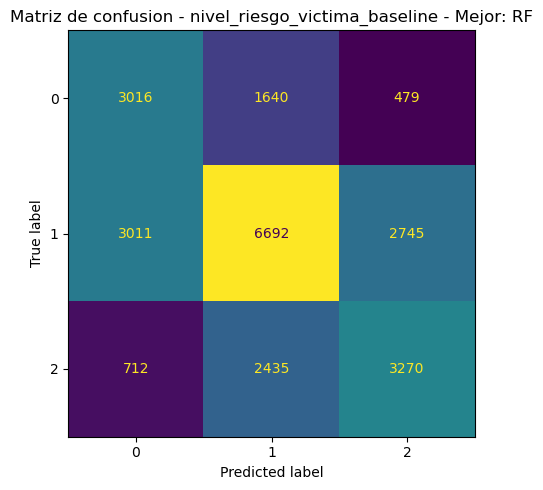

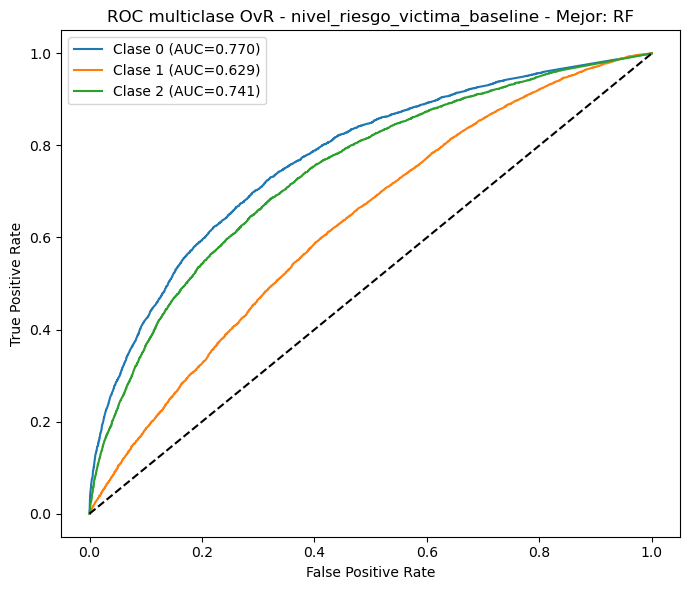

/usr/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Escenario baseline | Mejor modelo: RF | F1_macro=0.5217


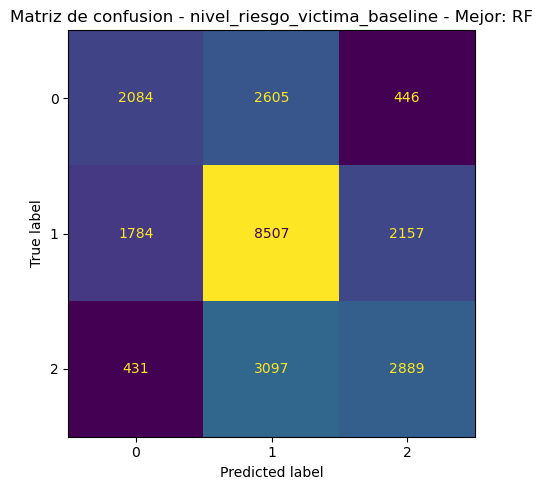

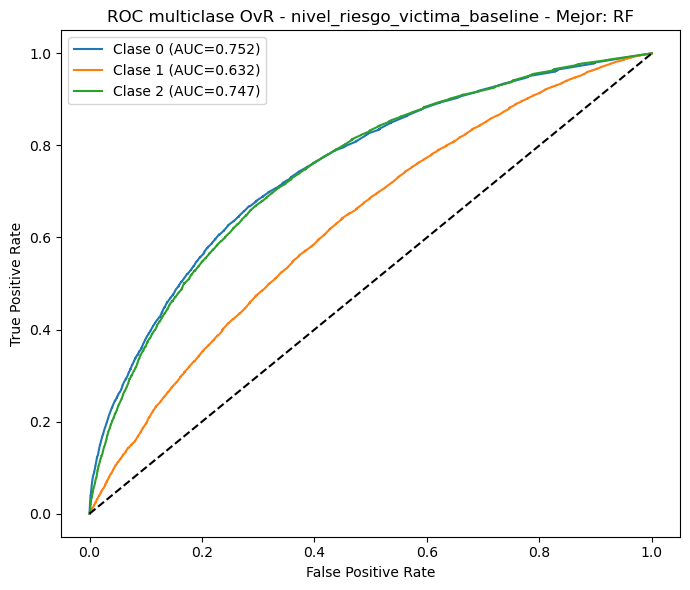

,target,scenario,model,f1_macro,n_features,n_train,n_test,subset_source,k
0,nivel_riesgo_victima,baseline,RF,0.530356,16,96000,24000,hibrido,16
1,nivel_riesgo_victima,baseline,MLP,0.469183,16,96000,24000,hibrido,16
2,nivel_riesgo_victima,baseline,RL,0.362573,16,96000,24000,hibrido,16
3,nivel_riesgo_victima,baseline,RF,0.521747,16,96000,24000,moes,16
4,nivel_riesgo_victima,baseline,MLP,0.380958,16,96000,24000,moes,16
5,nivel_riesgo_victima,baseline,RL,0.365153,16,96000,24000,moes,16


In [15]:
bench_riesgo = run_moes_vs_hibrido("nivel_riesgo_victima", k=16, random_state=42, sample_train=120000, run_smote=False, run_smotetomek=False)
display(bench_riesgo.sort_values(["subset_source", "scenario", "f1_macro"], ascending=[True, True, False]))
bench_riesgo.to_csv(f"{OUT}/benchmark_moes_vs_hibrido_nivel_riesgo_victima.csv", index=False)


In [16]:
benchmark_moes_vs_hibrido = pd.concat([bench_tipo, bench_riesgo], ignore_index=True)
benchmark_moes_vs_hibrido.to_csv(f"{OUT}/benchmark_moes_vs_hibrido.csv", index=False)
display(benchmark_moes_vs_hibrido.sort_values(["target", "subset_source", "f1_macro"], ascending=[True, True, False]))
print("Generado:", f"{OUT}/benchmark_moes_vs_hibrido.csv")


,target,scenario,model,f1_macro,n_features,n_train,n_test,subset_source,k
6,nivel_riesgo_victima,baseline,RF,0.530356,16,96000,24000,hibrido,16
7,nivel_riesgo_victima,baseline,MLP,0.469183,16,96000,24000,hibrido,16
8,nivel_riesgo_victima,baseline,RL,0.362573,16,96000,24000,hibrido,16
9,nivel_riesgo_victima,baseline,RF,0.521747,16,96000,24000,moes,16
10,nivel_riesgo_victima,baseline,MLP,0.380958,16,96000,24000,moes,16
11,nivel_riesgo_victima,baseline,RL,0.365153,16,96000,24000,moes,16
0,tipo_violencia,baseline,RL,0.970027,22,96000,24000,hibrido,22
1,tipo_violencia,baseline,MLP,0.969389,22,96000,24000,hibrido,22
2,tipo_violencia,baseline,RF,0.968706,22,96000,24000,hibrido,22
3,tipo_violencia,baseline,MLP,0.962996,22,96000,24000,moes,22


Generado: /home/munasqa/MAESTRIA/opencode/benchmark_moes_vs_hibrido.csv


## 16) Conclusiones de cierre de etapa

- Se realizo un benchmark directo entre subset **MOES** y subset **Hibrido** bajo condiciones equivalentes (mismo K, mismo split y mismos modelos base).
- En `tipo_violencia` (K=22), el subset hibrido mostro mejor F1-macro en `RL`, `MLP` y `RF` frente al subset MOES.
- En `nivel_riesgo_victima` (K=16), el mejor resultado tambien se obtuvo con `RF` sobre subset hibrido; MOES solo supero levemente en `RL` pero con desempeno global bajo.
- En esta etapa baseline, no se evidencia superioridad global de MOES en desempeno final.
- Decision de etapa: usar el subset hibrido como referencia principal para la siguiente fase de modelado y despliegue, manteniendo MOES como contraste metodologico.

### Siguiente fase (nuevo notebook)
1. Pipeline de produccion del modelo final y desarrollo de app de inferencia.
2. Interpretacion formal de matrices de confusion y errores por clase del mejor modelo.
3. Explicabilidad de variables finales (SHAP para modelos de arbol; analisis complementario para MLP).

## 17) Validacion focalizada de balanceo (RF final: baseline vs SMOTE vs SMOTETomek)
Este bloque prueba solo el modelo final (RF) con el subset hibrido por target para decidir si el balanceo mejora realmente el resultado.

In [19]:
from sklearn.metrics import f1_score, balanced_accuracy_score, recall_score

def eval_rf_balance_only(target, feature_list, random_state=42, sample_train=120000):
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier

    try:
        from imblearn.over_sampling import SMOTE as _SMOTE
        from imblearn.combine import SMOTETomek as _SMOTETomek
    except Exception:
        _SMOTE = None
        _SMOTETomek = None

    y = pd.to_numeric(df[target], errors="coerce")
    mask = y.notna()
    y = y[mask].astype(int)
    X = X_raw.loc[mask, feature_list].copy()
    X = _encode_for_training(X)

    if len(y) > sample_train:
        _, X, _, y = train_test_split(X, y, test_size=sample_train, stratify=y, random_state=random_state)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)

    scenarios = [("baseline", None)]
    if _SMOTE is not None:
        scenarios.append(("smote", _SMOTE(random_state=random_state)))
    if _SMOTETomek is not None:
        scenarios.append(("smotetomek", _SMOTETomek(random_state=random_state)))

    rows = []
    for name, sampler in scenarios:
        Xtr_use, ytr_use = Xtr.copy(), ytr.copy()
        if sampler is not None:
            Xtr_use, ytr_use = sampler.fit_resample(Xtr_use, ytr_use)

        rf = RandomForestClassifier(n_estimators=120, random_state=random_state, n_jobs=2, class_weight="balanced_subsample")
        rf.fit(Xtr_use, ytr_use)
        pred = rf.predict(Xte)

        rows.append({
            "target": target,
            "scenario": name,
            "model": "RF",
            "f1_macro": float(f1_score(yte, pred, average="macro")),
            "balanced_accuracy": float(balanced_accuracy_score(yte, pred)),
            "recall_macro": float(recall_score(yte, pred, average="macro")),
            "n_features": len(feature_list),
            "n_train": len(Xtr_use),
            "n_test": len(Xte),
        })

    return pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)


In [20]:
# Ejecutar por target con subset hibrido final
rf_balance_tipo = eval_rf_balance_only("tipo_violencia", final_features["tipo_violencia"], random_state=42, sample_train=120000)
rf_balance_riesgo = eval_rf_balance_only("nivel_riesgo_victima", final_features["nivel_riesgo_victima"], random_state=42, sample_train=120000)

display(rf_balance_tipo)
display(rf_balance_riesgo)

rf_balance_resumen = pd.concat([rf_balance_tipo, rf_balance_riesgo], ignore_index=True)
rf_balance_resumen.to_csv(f"{OUT}/rf_balanceo_comparativo.csv", index=False)
print("Generado:", f"{OUT}/rf_balanceo_comparativo.csv")


,target,scenario,model,f1_macro,balanced_accuracy,recall_macro,n_features,n_train,n_test
0,tipo_violencia,baseline,RF,0.968706,0.970061,0.970061,22,96000,24000


,target,scenario,model,f1_macro,balanced_accuracy,recall_macro,n_features,n_train,n_test
0,nivel_riesgo_victima,baseline,RF,0.530356,0.544841,0.544841,16,96000,24000


Generado: /home/munasqa/MAESTRIA/opencode/rf_balanceo_comparativo.csv
